In [125]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.neighbors import NearestNeighbors

In [126]:
#load datasets
ratings = pd.read_csv('data/ratings.dat', sep='::', engine='python', header=None,
                    names=['UserID','MovieID','Rating','Timestamp'])
movies = pd.read_csv('data/movies.dat', sep='::', engine='python', header=None, encoding='latin-1',
                         names=['MovieID','Title','Genres'])
users = pd.read_csv('data/users.dat', sep='::', engine='python', header=None,
                        names=['UserID','Gender','Age','Occupation','Zip'])

In [127]:
#merge ratings and movies on movieId, users are demographic filtering which could be optional to include later.
#we focus on collaborative filtering based on user behavior, and content based filtering focussing on movie features
df = pd.merge(ratings, movies, on='MovieID')
df.head()

,UserID,MovieID,Rating,Timestamp,Title,Genres
0,1,1193,5,978300760,One Flew Over the Cuckoo's Nest (1975),Drama
1,1,661,3,978302109,James and the Giant Peach (1996),Animation|Children's|Musical
2,1,914,3,978301968,My Fair Lady (1964),Musical|Romance
3,1,3408,4,978300275,Erin Brockovich (2000),Drama
4,1,2355,5,978824291,"Bug's Life, A (1998)",Animation|Children's|Comedy


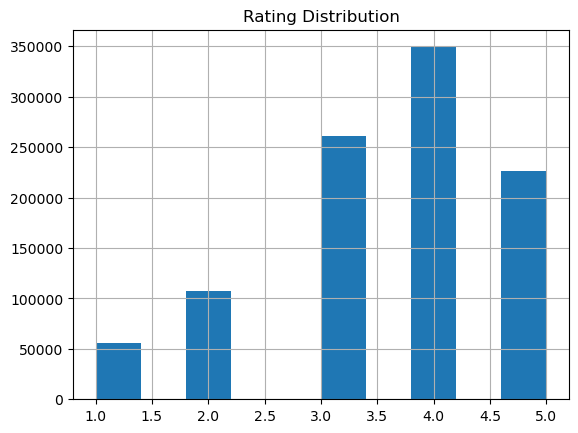

In [128]:
#rating distribution
df['Rating'].hist()
plt.title("Rating Distribution")
plt.show()
#most movies are rated 4 and 3 out of 5

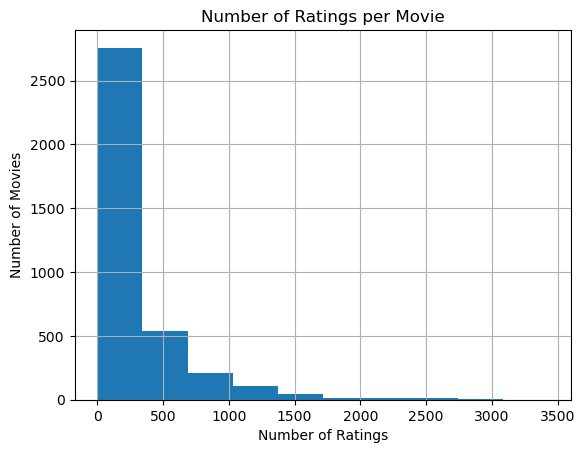

In [129]:
#number of ratings per movie
df.groupby('MovieID')['Rating'].count().hist()
plt.title("Number of Ratings per Movie")
plt.xlabel("Number of Ratings")
plt.ylabel("Number of Movies")
plt.show()
#most movies have < 500 ratings, data is imbalanced

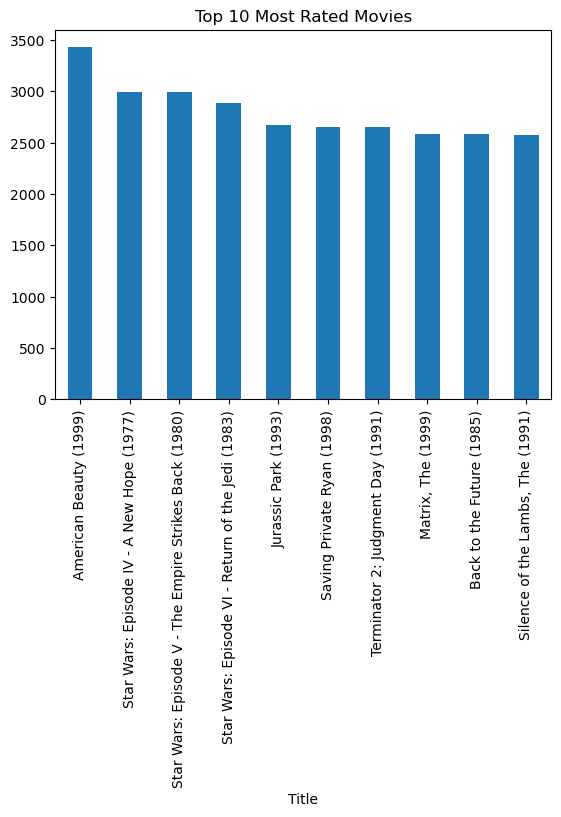

In [130]:
#popular movies
top_movies = df.groupby('Title')['Rating'].count().sort_values(ascending=False).head(10)
top_movies.plot(kind='bar')
plt.title("Top 10 Most Rated Movies")
plt.show()

In [131]:
#check if there are null values
df.isnull().sum()

UserID       0
MovieID      0
Rating       0
Timestamp    0
Title        0
Genres       0
dtype: int64

In [132]:
#understand the data
movie_counts = df.groupby('MovieID')['Rating'].count()
movie_counts.describe()

count    3706.000000
mean      269.889099
std       384.047838
min         1.000000
25%        33.000000
50%       123.500000
75%       350.000000
max      3428.000000
Name: Rating, dtype: float64

In [133]:
#Although the datasets contain about 3900 movies in total, after merging with ratings only 3706 remain.
#For 3706 movies, there are ~270 ratings per movie on average. Range: 1-3428 ratings.
#75% of the movies have <= 350 ratings which shows that the dataset is highly imbalanced

In [134]:
#Creating the User-Item Matrix
user_item_matrix = df.pivot_table(
    index = 'UserID',
    columns = 'MovieID',
    values = 'Rating'
).fillna(0)
user_item_matrix.head()

MovieID,1,2,3,4,5,6,7,8,9,10,...,3943,3944,3945,3946,3947,3948,3949,3950,3951,3952
UserID,,,,,,,,,,,,,,,,,,,,,
1,5.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
5,0.0,0.0,0.0,0.0,0.0,2.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [135]:
#Transpose
#We created a new matrix where each row corresponds to one movie and the columns are users
#The values correspond to the ratings, NaN values are filled with 0
movie_matrix = user_item_matrix.T
movie_matrix.head()

UserID,1,2,3,4,5,6,7,8,9,10,...,6031,6032,6033,6034,6035,6036,6037,6038,6039,6040
MovieID,,,,,,,,,,,,,,,,,,,,,
1,5.0,0.0,0.0,0.0,0.0,4.0,0.0,4.0,5.0,5.0,...,0.0,4.0,0.0,0.0,4.0,0.0,0.0,0.0,0.0,3.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,5.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3.0,0.0,0.0,...,0.0,0.0,0.0,0.0,2.0,2.0,0.0,0.0,0.0,0.0
5,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0


In [136]:
#KNN requires to have a vector, so we set each movie to be a point which is defined by all ratings.

In [137]:
#Create the model
#We use cosine similarity to measure the direction of the vectors rather than distance of the points.
#We don't want to compare numbers but find patterns in ratings.
#brute algorithm compares a movie to all others
knn = NearestNeighbors(metric='cosine', algorithm='brute')
knn.fit(movie_matrix)

,n_neighbors,5
,radius,1.0
,algorithm,'brute'
,leaf_size,30
,metric,'cosine'
,p,2
,metric_params,None
,n_jobs,None


In [138]:
#function that returns 5 movie recommendation for a specific movie
#distances saves the similarity and indices saves location
#find that row, reshape it and return all the neighbours
def recommend(movie_id, n=10):
    distances, indices = knn.kneighbors(
        movie_matrix.loc[movie_id].values.reshape(1, -1),
        n_neighbors=n+1
    )
    #return indices
    return indices.flatten()[1:]

In [139]:
#recommend the movie by title
#uses the recommend function to find similar movies
#converts the IDs into their titles
def recommend_movies(title, n=10):
    movie_id = df[df['Title'] == title]['MovieID'].values[0]
    rec_ids = recommend(movie_id, n)
    return movies[movies['MovieID'].isin(rec_ids)]['Title']

In [140]:
#test
recommend_movies("Toy Story (1995)")

32                                Wings of Courage (1995)
342                                       Backbeat (1993)
570                            Spanking the Monkey (1994)
1090                              Leopard Son, The (1996)
1157      Cook the Thief His Wife & Her Lover, The (1989)
1162                                Paths of Glory (1957)
1424                           Waiting for Guffman (1996)
2093    NeverEnding Story II: The Next Chapter, The (1...
2305                                       Gung Ho (1986)
2829                                Dark Half, The (1993)
Name: Title, dtype: object

In [141]:
#Collective filtering is done
#We created a system that recommends movies based on similar rankings
#Now we continue with content based similarity to get better recommendations

In [142]:
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.metrics.pairwise import cosine_similarity

In [143]:
#Put the genres into vectors
count = CountVectorizer(tokenizer=lambda x: x.split('|')) #splits multiple genres
genre_matrix = count.fit_transform(movies['Genres']) #learns genres & transforms into numbers
#create an array for visualization
genre_df = pd.DataFrame(genre_matrix.toarray(), columns=count.get_feature_names_out())
genre_df.head()

/opt/anaconda3/lib/python3.13/site-packages/sklearn/feature_extraction/text.py:517: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(


,action,adventure,animation,children's,comedy,crime,documentary,drama,fantasy,film-noir,horror,musical,mystery,romance,sci-fi,thriller,war,western
0,0,0,1,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0
1,0,1,0,1,0,0,0,0,1,0,0,0,0,0,0,0,0,0
2,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0
3,0,0,0,0,1,0,0,1,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0


In [144]:
#compare the movies to each other
cosine_sim = cosine_similarity(genre_matrix)

In [145]:
#find movie by title
indices = pd.Series(movies.index, index=movies['Title'])

In [146]:
#create a function to recommend by content
def content_recommend(title, n=10):
    idx = indices[title] #find the movie by index
    #similarity
    sim_scores = list(enumerate(cosine_sim[idx])) #get the similarity
    sim_scores = sorted(sim_scores, key=lambda x: x[1], reverse=True)[1:n+1] #sort by similarity
    movie_indices = [i[0] for i in sim_scores]
    return movies['Title'].iloc[movie_indices]

In [147]:
#test
content_recommend("Toy Story (1995)")

1050            Aladdin and the King of Thieves (1996)
2072                          American Tail, An (1986)
2073        American Tail: Fievel Goes West, An (1991)
2285                         Rugrats Movie, The (1998)
2286                              Bug's Life, A (1998)
3045                                Toy Story 2 (1999)
3542                             Saludos Amigos (1943)
3682                                Chicken Run (2000)
3685    Adventures of Rocky and Bullwinkle, The (2000)
236                              Goofy Movie, A (1995)
Name: Title, dtype: object

In [148]:
#combine both models to create a hybrid of rankings and content based similarity
#creating a ranking with scores
def hybrid_recommend(title, n=10):
    #find the recommended movies for both
    collab = list(recommend_movies(title, n))
    content = list(content_recommend(title, n))

    scores = {}

    # content (more priority), give points to each movie, first k has most points, last k has least
    for i, movie in enumerate(content):
        scores[movie] = scores.get(movie, 0) + (n - i)

    # collab (less priority), gets same ranking but smaller weight so * 0.7
    for i, movie in enumerate(collab):
        scores[movie] = scores.get(movie, 0) + (n - i) * 0.7
        
    #sort by scores
    sorted_movies = sorted(scores.items(), key=lambda x: x[1], reverse=True)

    return [m[0] for m in sorted_movies[:n]]

In [149]:
#test
hybrid_recommend("Toy Story (1995)")

['Aladdin and the King of Thieves (1996)',
 'American Tail, An (1986)',
 'American Tail: Fievel Goes West, An (1991)',
 'Rugrats Movie, The (1998)',
 'Wings of Courage (1995)',
 'Backbeat (1993)',
 "Bug's Life, A (1998)",
 'Spanking the Monkey (1994)',
 'Toy Story 2 (1999)',
 'Leopard Son, The (1996)']